In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('data.csv')
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
churn = data[data['churn'] == 1]
stay = data[data['churn'] == 0]

In [13]:
data.active_member.describe()

count    10000.000000
mean         0.515100
std          0.499797
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: active_member, dtype: float64

In [4]:
plt.style.available

plt.style.use('Solarize_Light2')

/var/folders/kz/rts6j3mj2nj3xm6c6kf4t1h80000gn/T/ipykernel_16118/2124789878.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(labelcolor='black')


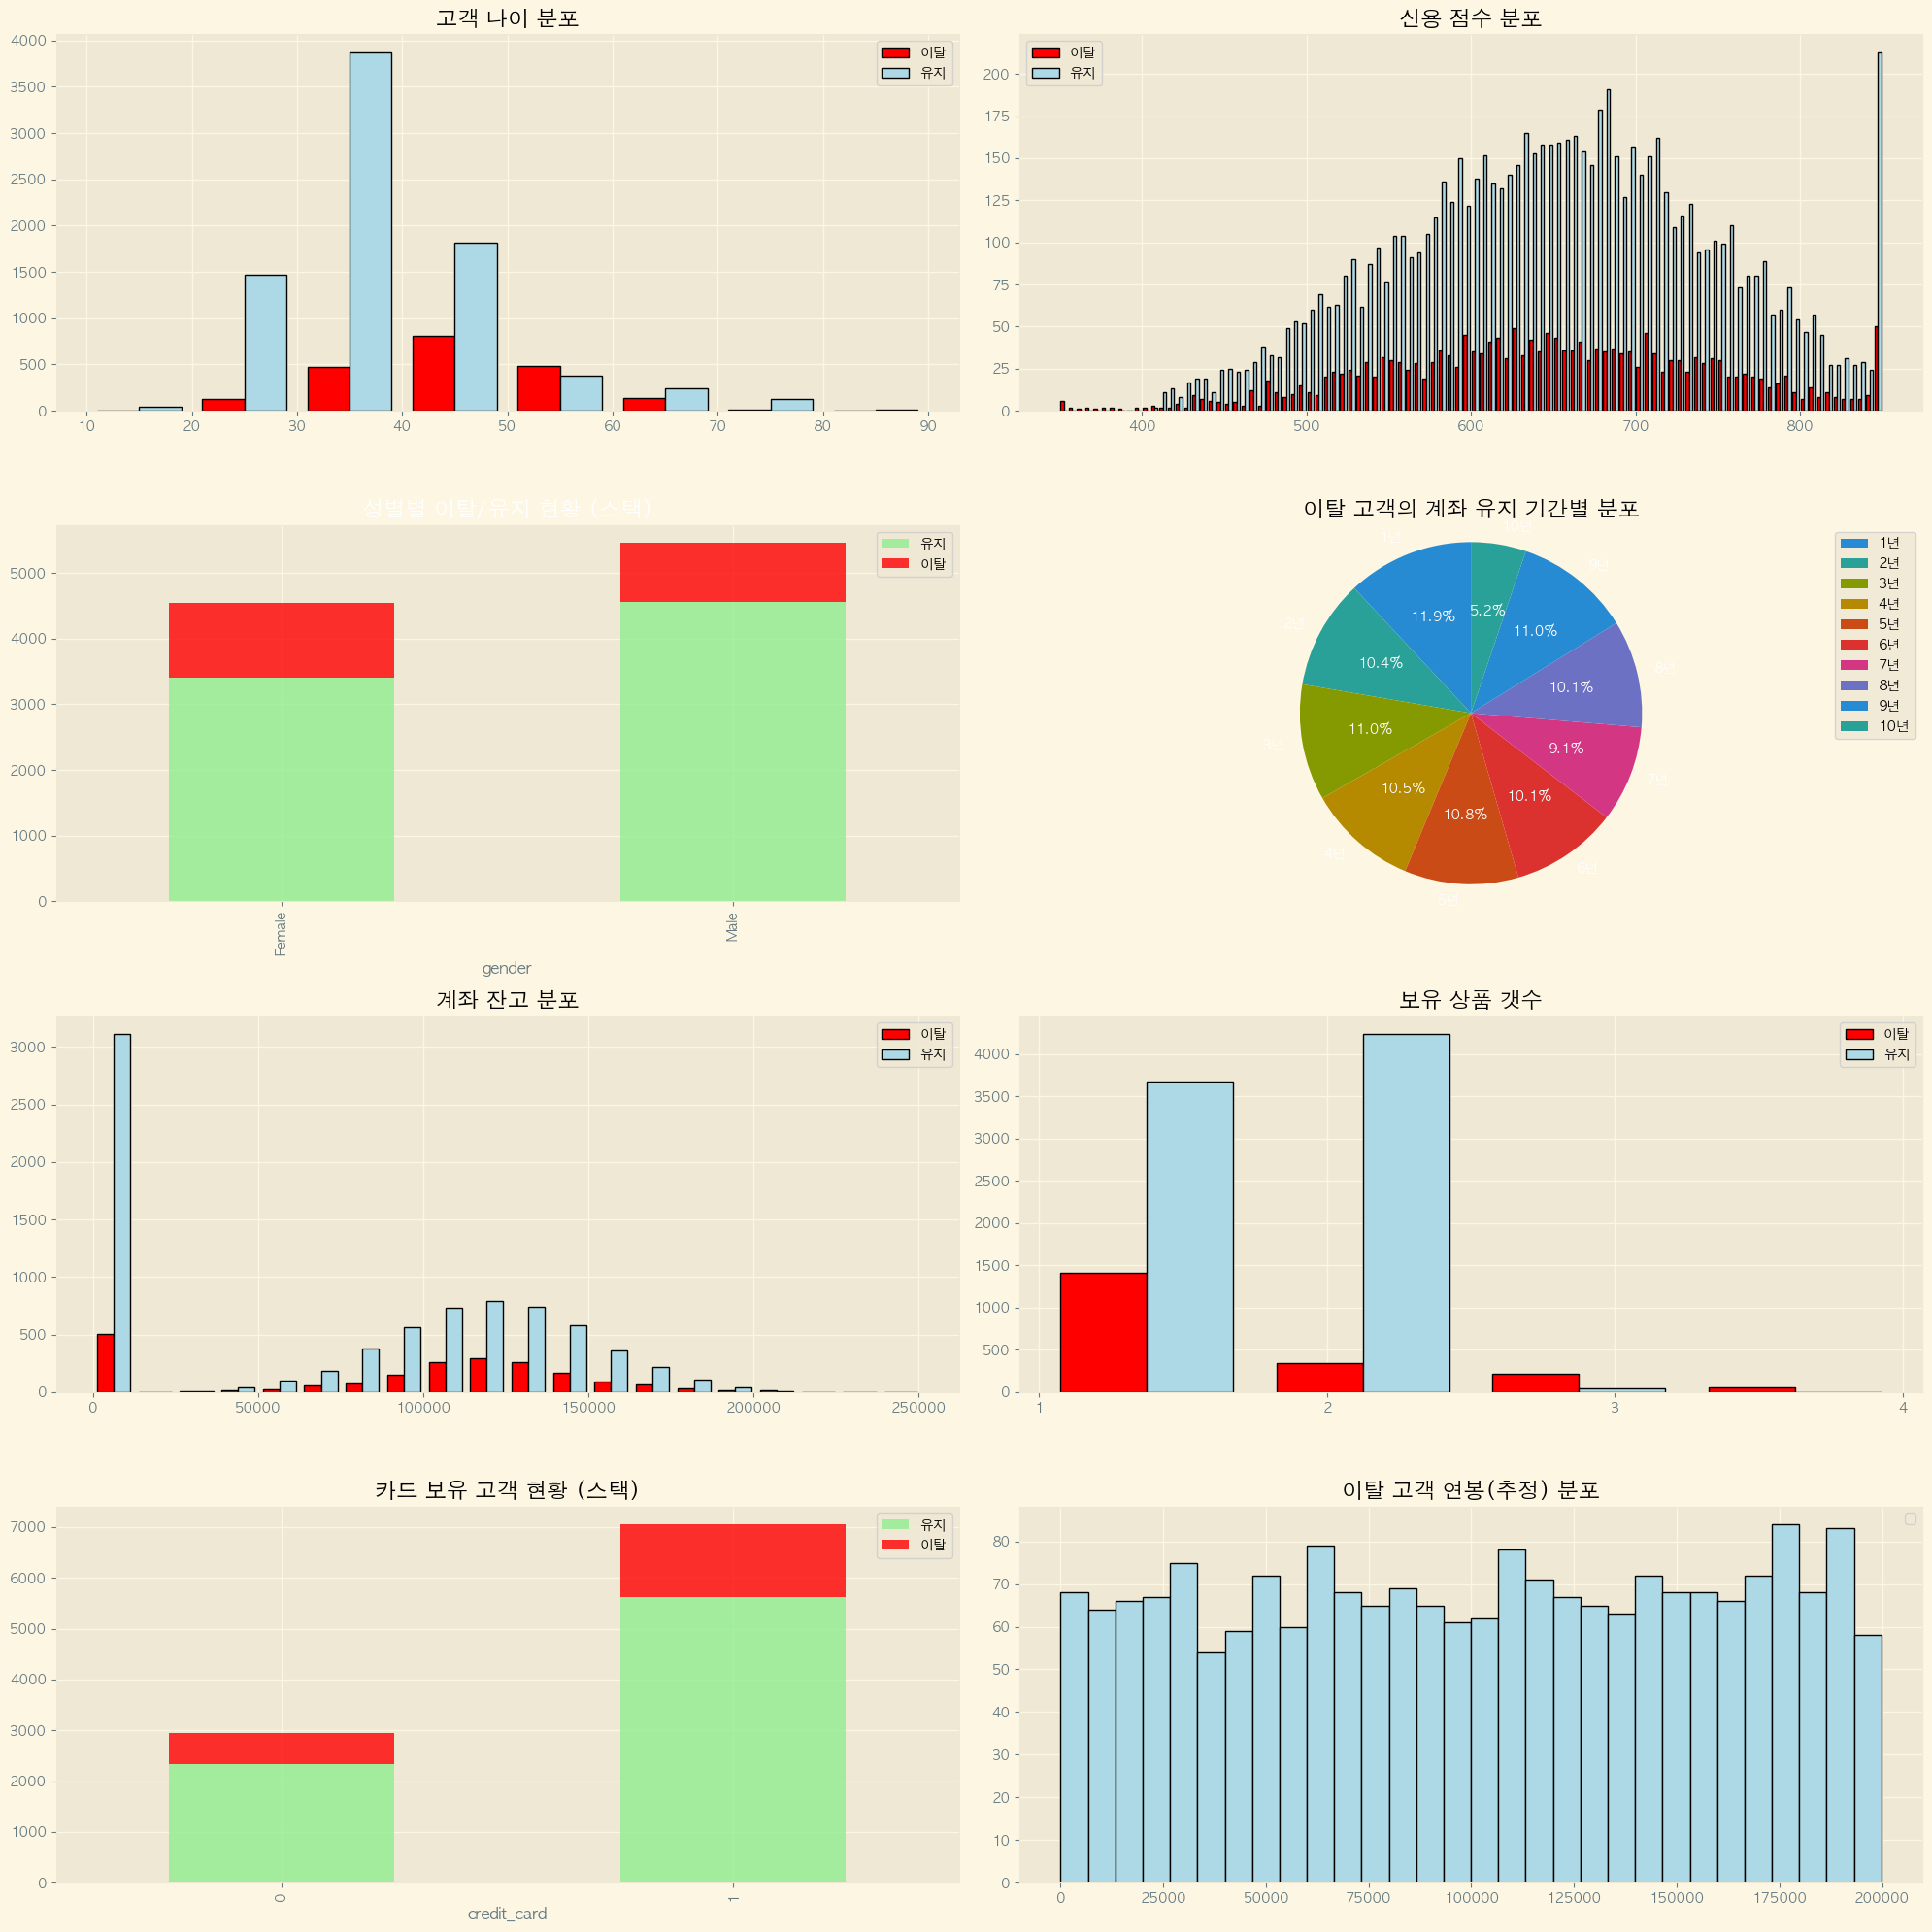

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))
plt.legend(labelcolor='black')

ages = axes[0, 0]
ages.set_title('고객 나이 분포', color='black')
ages_bins = [x*10 for x in range(1, 10)]
ages.hist([churn.age, stay.age], bins=ages_bins, color=['red','lightblue'], edgecolor='black', label=['이탈', '유지'])
ages.legend(labelcolor='black')


credit_score = axes[0, 1]
credit_score.set_title('신용 점수 분포',color='black')
credit_score.hist([churn.credit_score, stay.credit_score], bins=100, color=['red','lightblue'], edgecolor='black', label=['이탈', '유지'])
credit_score.legend(labelcolor='black')

gender_ax = axes[1,0]
gender_ax.set_title('성별별 이탈/유지 현황 (스택)')
gender_counts = data.groupby(['gender', 'churn']).size().unstack(fill_value=0)
gender_counts.plot(kind='bar', ax=gender_ax, stacked=True, 
                   color=['lightgreen', 'red'], alpha=0.8)
gender_ax.legend(['유지', '이탈'], labelcolor='black')

tenure = axes[1, 1]
tenure.set_title('이탈 고객의 계좌 유지 기간별 분포', color='black')
# tenure를 구간별로 나누어 파이 차트 생성
tenure_bins = pd.cut(churn['tenure'], bins=[x for x in range(0, 11)], labels=[f'{x}년' for x in range(1, 11)])
tenure_counts = tenure_bins.value_counts().sort_index()  # 인덱스(년도) 순서대로 정렬
tenure.pie(tenure_counts.values, labels=tenure_counts.index, autopct='%1.1f%%', startangle=90)
tenure.legend(labelcolor='black')
tenure.axis('equal')  # 원형으로 만들기


balance_ax = axes[2, 0]
balance_ax.set_title('계좌 잔고 분포',color='black')
balance_ax.hist([churn.balance, stay.balance], bins=20, color=['red','lightblue'], edgecolor='black', label=['이탈', '유지'])
balance_ax.legend(labelcolor='black')


products_number_ax = axes[2,1]
products_number_ax.set_title('보유 상품 갯수',color='black')
products_number_ax.hist([churn.products_number, stay.products_number], bins=4, color=['red','lightblue'], edgecolor='black', label=['이탈', '유지'])
products_number_ax.set_xticks([1, 2, 3, 4])
products_number_ax.legend(labelcolor='black')

credit_card_ax = axes[3,0]
credit_card_ax.set_title('카드 보유 고객 현황 (스택)',color='black')
credit_card = data.groupby(['credit_card', 'churn']).size().unstack(fill_value=0)
credit_card.plot(kind='bar', ax=credit_card_ax, stacked=True, 
                   color=['lightgreen', 'red'], alpha=0.8)
credit_card_ax.legend(['유지', '이탈'], labelcolor='black')


salary_ax = axes[3,1]
salary_ax.set_title('이탈 고객 연봉(추정) 분포', color='black')
salary_ax.hist(churn.estimated_salary, bins=30, color='lightblue', edgecolor='black')

plt.tight_layout()
plt.show()

In [16]:
# 결측치 없음
data.isna().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [17]:
# 이상치 확인
# data.credit_score.describe() # 이상치 없음
# data.age.describe() # 이상치 없음
# data.tenure.describe() # 이상치 없음
# data.balance.describe() # 편차가 큼 0이 많음
# data.products_number.describe() # 이상치 없음
data.estimated_salary.describe() # 이상치 없음

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: estimated_salary, dtype: float64

<Axes: >

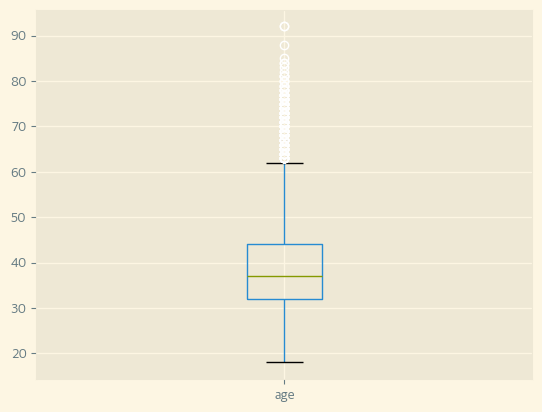

In [22]:
result = data.drop('customer_id', axis=1)
result[['age']].boxplot()